In [6]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Código para calcular correlación entre estaciones para una variable dada (por defecto O3).
Lee archivos CSV de una carpeta (por ejemplo, los originales o los imputados),
alinea las series por fecha y calcula la matriz de correlación.
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ============================================================================
# CONFIGURACIÓN (modifica según tu caso)
# ============================================================================

# Carpeta donde están los CSV de cada estación (puede ser la original o imputed_global)
DATA_DIR = os.path.expanduser("/Volumes/copia seguridad1/enviar_benja/imputed_global/")

# Variable a correlacionar (columna)
VAR = 'O3'

# Método de correlación: 'pearson', 'spearman', 'kendall'
CORR_METHOD = 'pearson'

# Umbral mínimo de datos comunes (fracción) para considerar un par de estaciones
MIN_COMMON_FRAC = 0.3   # al menos 30% de horas en común

# Guardar gráficos y tablas
OUTPUT_DIR = os.path.expanduser("~/Documents/GitHub/TFGFinal/correlaciones_estaciones")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================================
# FUNCIONES AUXILIARES
# ============================================================================

def clean_series(serie):
    """
    Asegura que la serie tenga índice único y ordenado.
    - Elimina duplicados de índice (conserva el primero)
    - Ordena por índice
    - Convierte a numérico (coerce)
    """
    # Forzar tipo numérico
    serie = pd.to_numeric(serie, errors='coerce')
    # Eliminar duplicados de índice (keep='first' mantiene el primero)
    if not serie.index.is_unique:
        serie = serie[~serie.index.duplicated(keep='first')]
    # Ordenar índice
    serie = serie.sort_index()
    return serie

def load_station_data(filepath, var):
    """Carga un CSV, asume índice datetime, devuelve Serie limpia con la variable."""
    df = pd.read_csv(filepath, index_col=0, parse_dates=True)
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)
    if var not in df.columns:
        raise ValueError(f"Variable '{var}' no encontrada en {filepath}")
    serie = df[var].copy()
    serie = clean_series(serie)
    return serie

def get_series_from_folder(folder_path, var):
    """
    Recorre todos los archivos CSV en folder_path y devuelve un dict {nombre: Serie}.
    Si el archivo contiene varias estaciones (columna 'Estacion'), extrae cada una.
    Cada serie es limpiada (índice único y ordenado).
    """
    series_dict = {}
    files = list(Path(folder_path).glob("*.csv"))
    for f in files:
        name = f.stem
        df = pd.read_csv(f, index_col=0, parse_dates=True)
        if not isinstance(df.index, pd.DatetimeIndex):
            df.index = pd.to_datetime(df.index)
        # Verificar si tiene columna 'Estacion' (caso por transecto)
        if 'Estacion' in df.columns:
            # Agrupar por estación
            for estacion, group in df.groupby('Estacion'):
                if var in group.columns:
                    serie = group[var].copy()
                    serie = clean_series(serie)
                    series_dict[f"{name}_{estacion}"] = serie
        else:
            # Archivo de una sola estación
            if var in df.columns:
                serie = df[var].copy()
                serie = clean_series(serie)
                series_dict[name] = serie
    return series_dict

def align_series(series_dict):
    """Alinea todas las series por índice de tiempo (unión externa) y devuelve DataFrame."""
    # Asegurar que todas las series tienen índice ordenado y único (ya lo hicimos en get_series)
    # Concatenar
    df_all = pd.concat(series_dict, axis=1)
    # Renombrar columnas si son MultiIndex (por si acaso)
    df_all.columns = [col if isinstance(col, str) else col[1] for col in df_all.columns]
    return df_all

def compute_correlation_matrix(df, method='pearson', min_common_frac=0.5):
    """
    Calcula matriz de correlación entre columnas, ignorando pares con pocos datos comunes.
    """
    n = len(df)
    min_common = int(n * min_common_frac)
    corr_matrix = pd.DataFrame(index=df.columns, columns=df.columns, dtype=float)
    for i, col1 in enumerate(df.columns):
        for j, col2 in enumerate(df.columns):
            if i == j:
                corr_matrix.loc[col1, col2] = 1.0
                continue
            # Datos no nulos en ambos
            mask = df[col1].notna() & df[col2].notna()
            if mask.sum() < min_common:
                corr_matrix.loc[col1, col2] = np.nan
            else:
                corr_matrix.loc[col1, col2] = df[col1][mask].corr(df[col2][mask], method=method)
    return corr_matrix

def plot_correlation_heatmap(corr_matrix, title, save_path):
    """Dibuja mapa de calor de la matriz de correlación."""
    plt.figure(figsize=(12, 10))
    mask = corr_matrix.isna()
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                square=True, linewidths=0.5, mask=mask,
                cbar_kws={'shrink': 0.8})
    plt.title(title, fontsize=14)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close()
    print(f"  Gráfico guardado: {save_path}")

def plot_correlation_clustermap(corr_matrix, title, save_path):
    """Mapa de calor con clustering jerárquico."""
    if corr_matrix.isna().all().all():
        print("  Matriz vacía, no se puede generar clustermap.")
        return
    # Reemplazar NaN por 0 para que no rompa el clustering (pero puede distorsionar)
    corr_filled = corr_matrix.fillna(0)
    g = sns.clustermap(corr_filled, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                       figsize=(12, 10), linewidths=0.5,
                       cbar_kws={'shrink': 0.8})
    g.ax_heatmap.set_title(title)
    plt.savefig(save_path, dpi=150)
    plt.close()
    print(f"  Clustermap guardado: {save_path}")

# ============================================================================
# EJECUCIÓN PRINCIPAL
# ============================================================================

if __name__ == "__main__":
    print("="*60)
    print(f"Cálculo de correlación ({CORR_METHOD}) para variable '{VAR}'")
    print("="*60)

    # 1. Cargar series
    print(f"\nCargando datos desde: {DATA_DIR}")
    series = get_series_from_folder(DATA_DIR, VAR)
    if not series:
        print("No se encontraron series válidas. Revise la carpeta.")
        exit()
    print(f"Estaciones encontradas: {list(series.keys())}")

    # 2. Alinear temporalmente
    df_aligned = align_series(series)
    print(f"Periodo: {df_aligned.index.min()} a {df_aligned.index.max()}")
    print(f"Total de horas: {len(df_aligned)}")

    # 3. Calcular matriz de correlación
    corr_matrix = compute_correlation_matrix(df_aligned, method=CORR_METHOD,
                                              min_common_frac=MIN_COMMON_FRAC)
    # Guardar matriz en CSV
    corr_csv = os.path.join(OUTPUT_DIR, f"correlacion_{VAR}_{CORR_METHOD}.csv")
    corr_matrix.to_csv(corr_csv)
    print(f"\nMatriz de correlación guardada en: {corr_csv}")

    # 4. Generar gráficos
    title = f"Correlación {CORR_METHOD} de {VAR} entre estaciones"
    plot_correlation_heatmap(corr_matrix, title,
                             os.path.join(OUTPUT_DIR, f"heatmap_{VAR}_{CORR_METHOD}.png"))
    plot_correlation_clustermap(corr_matrix, title,
                                os.path.join(OUTPUT_DIR, f"clustermap_{VAR}_{CORR_METHOD}.png"))

    # 5. Mostrar las 10 correlaciones más altas (fuera de la diagonal)
    # Obtener matriz triangular superior sin diagonal
    corr_triu = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    corr_triu = corr_triu.unstack().dropna().sort_values(ascending=False)
    if not corr_triu.empty:
        print("\nTop 10 pares con mayor correlación:")
        for (col1, col2), val in corr_triu.head(10).items():
            print(f"  {col1} vs {col2}: {val:.3f}")
    else:
        print("\nNo hay pares con suficientes datos comunes.")

    print("\nProceso completado. Revise la carpeta:")
    print(f"  {OUTPUT_DIR}")

Cálculo de correlación (pearson) para variable 'O3'

Cargando datos desde: /Volumes/copia seguridad1/enviar_benja/imputed_global/
Estaciones encontradas: ['T1_E1_Alicante_Estacion 1', 'T1_E2_Elda_Estacion 2', 'T1_E2_Elda_T1_E2_Elda', 'T2_E1_Elche_Estacion 1', 'T2_E1_Elche_T2_E1_Elche', 'T2_E2_Elda_Estacion 2', 'T2_E2_Elda_T2_E2_Elda', 'T3_E1_Valencia_Estacion 1', 'T3_E2_Buñol_Estacion 2', 'T4_E1_Valencia_Estacion 1', 'T4_E2_Villar_Arzobispo_Estacion 2', 'T6_E1_Castellon_Estacion 1', 'T6_E1_Castellon_T6_E1_Castellon', 'T6_E2_Onda_Estacion 2', 'T7_E1_Sant_Jordi_Estacion 1', 'T7_E2_Coratxa_Estacion 2', 'T7_E3_Zorita_Estacion 3', 'T8_E1_Sant_Jordi_Estacion 1', 'T8_E2_Morella_Estacion 2', 'T8_E3_Zorita_Estacion 3']
Periodo: 2006-01-01 00:00:00 a 2068-01-01 00:00:00
Total de horas: 320214

Matriz de correlación guardada en: /Users/benjamincarbonell/Documents/GitHub/TFGFinal/correlaciones_estaciones/correlacion_O3_pearson.csv
  Gráfico guardado: /Users/benjamincarbonell/Documents/GitHub/TFGF

In [ ]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
from itertools import product

# ============================================================================
# CONFIGURACIÓN (modificar según tu caso)
# ============================================================================
DATA_DIR = "/Volumes/copia seguridad1/enviar_benja/carpeta sin título/clean/Finales/"
VAR_LIST = ['NO', 'NO2', 'O3']
LAG_MIN = -24
LAG_MAX = 24
STEP = 1
CORR_METHOD = 'pearson'
USE_TRANSECT = False
TRANSECT_FILE = ""
LIMIT_STATIONS = None
MIN_COMMON_FRAC = 0.2

# Función para extraer la ciudad (o identificador de ubicación) del nombre de estación
def extract_location(station_name):
    # Ejemplo: "T1_E1_Alicante" -> "Alicante"
    # Si el nombre tiene guiones bajos, toma la última parte
    parts = station_name.split('_')
    return parts[-1] if len(parts) > 1 else station_name

# ============================================================================
# FUNCIONES
# ============================================================================
def load_all_series(data_dir, var_list, use_transect=False, transect_path=None, limit_stations=None):
    series_dict = {}  # clave: (nombre_estacion, variable) -> (serie, ubicacion)
    if use_transect:
        df = pd.read_csv(transect_path, index_col=0, parse_dates=True, low_memory=False)
        if not isinstance(df.index, pd.DatetimeIndex):
            df.index = pd.to_datetime(df.index)
        estaciones = df['Estacion'].unique()
        if limit_stations:
            estaciones = [e for e in estaciones if e in limit_stations]
        for est in estaciones:
            df_est = df[df['Estacion'] == est]
            for var in var_list:
                if var in df_est.columns:
                    serie = pd.to_numeric(df_est[var], errors='coerce')
                    serie = serie.groupby(serie.index).first()
                    series_dict[(est, var)] = (serie, extract_location(est))
    else:
        files = list(Path(data_dir).glob("*.csv"))
        for f in files:
            est_name = f.stem
            if limit_stations and est_name not in limit_stations:
                continue
            df = pd.read_csv(f, index_col=0, parse_dates=True, low_memory=False)
            if not isinstance(df.index, pd.DatetimeIndex):
                df.index = pd.to_datetime(df.index)
            for var in var_list:
                if var in df.columns:
                    serie = pd.to_numeric(df[var], errors='coerce')
                    series_dict[(est_name, var)] = (serie, extract_location(est_name))
    return series_dict

def cross_correlation(serie1, serie2, lags, method='pearson', min_common=100):
    combined = pd.concat([serie1, serie2], axis=1).dropna()
    if len(combined) < min_common:
        return {lag: np.nan for lag in lags}
    s1 = combined.iloc[:, 0]
    s2 = combined.iloc[:, 1]
    results = {}
    for lag in lags:
        if lag >= 0:
            corr = s1.corr(s2.shift(-lag), method=method)
        else:
            corr = s1.shift(lag).corr(s2, method=method)
        results[lag] = corr
    return results

def compute_all_correlations(series_dict, lags, method='pearson', min_common_frac=0.3):
    stations_vars = list(series_dict.keys())
    total_pairs = len(stations_vars) * len(stations_vars) * len(lags)
    print(f"Calculando {total_pairs} combinaciones...")
    min_common = int(min(len(series_dict[k][0]) for k in series_dict) * min_common_frac)
    min_common = max(min_common, 10)
    results = []
    for (est1, var1), (est2, var2) in product(stations_vars, repeat=2):
        # Excluir si es la misma estación (mismo nombre completo)
        if est1 == est2:
            continue
        # Excluir si representan la misma ubicación (ciudad)
        loc1 = series_dict[(est1, var1)][1]
        loc2 = series_dict[(est2, var2)][1]
        if loc1 == loc2:
            continue
        serie1 = series_dict[(est1, var1)][0]
        serie2 = series_dict[(est2, var2)][0]
        corr_dict = cross_correlation(serie1, serie2, lags, method=method, min_common=min_common)
        for lag, corr in corr_dict.items():
            if not np.isnan(corr):
                results.append((est1, var1, est2, var2, lag, corr))
    return results

# ============================================================================
# EJECUCIÓN
# ============================================================================
if __name__ == "__main__":
    print("="*60)
    print("Cálculo de correlaciones cruzadas (excluyendo misma estación y misma ubicación)")
    print("="*60)

    series = load_all_series(DATA_DIR, VAR_LIST, USE_TRANSECT, TRANSECT_FILE, LIMIT_STATIONS)
    if not series:
        print("No se encontraron series.")
        exit()
    print(f"Series cargadas: {len(series)}")

    lags = list(range(LAG_MIN, LAG_MAX+1, STEP))
    print(f"Rango de lags: {LAG_MIN} a {LAG_MAX} (paso {STEP}) -> {len(lags)} lags")

    results = compute_all_correlations(series, lags, method=CORR_METHOD, min_common_frac=MIN_COMMON_FRAC)
    print(f"Combinaciones válidas: {len(results)}")

    if len(results) == 0:
        print("No hay resultados. Ajusta MIN_COMMON_FRAC o revisa los datos.")
        exit()

    df = pd.DataFrame(results, columns=['est_origen', 'var_origen', 'est_destino', 'var_destino', 'lag', 'correlacion'])

    top100_max = df.nlargest(100, 'correlacion')
    top100_min = df.nsmallest(100, 'correlacion')

    print("\n" + "="*60)
    print("TOP 100 CORRELACIONES MÁS ALTAS")
    print("="*60)
    print(top100_max.to_string(index=False))

    print("\n" + "="*60)
    print("TOP 100 CORRELACIONES MÁS BAJAS (más negativas)")
    print("="*60)
    print(top100_min.to_string(index=False))

    output_csv = "cross_correlations_all.csv"
    df.to_csv(output_csv, index=False)
    print(f"\nResultados completos guardados en {output_csv}")

    # Gráfico opcional
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].barh(range(100), top100_max['correlacion'].values)
    axes[0].set_yticks(range(100))
    axes[0].set_yticklabels([f"{row['est_origen']} {row['var_origen']} → {row['est_destino']} {row['var_destino']} (lag {row['lag']})" 
                             for _, row in top100_max.iterrows()], fontsize=8)
    axes[0].set_title("Top 100 correlaciones más altas")
    axes[0].invert_yaxis()
    axes[1].barh(range(100), top100_min['correlacion'].values, color='salmon')
    axes[1].set_yticks(range(100))
    axes[1].set_yticklabels([f"{row['est_origen']} {row['var_origen']} → {row['est_destino']} {row['var_destino']} (lag {row['lag']})" 
                             for _, row in top100_min.iterrows()], fontsize=8)
    axes[1].set_title("Top 100 correlaciones más bajas")
    axes[1].invert_yaxis()
    plt.tight_layout()
    plt.savefig("top_correlations.png", dpi=150)
    plt.show()
    print("Gráfico guardado como top_correlations.png")

Cálculo de correlaciones cruzadas (excluyendo misma estación y misma ubicación)
Series cargadas: 48
Rango de lags: -24 a 24 (paso 1) -> 49 lags
Calculando 112896 combinaciones...
Combinaciones válidas: 0
No hay resultados. Ajusta MIN_COMMON_FRAC o revisa los datos.


TypeError: Column 'correlacion' has dtype object, cannot use method 'nlargest' with this dtype

: 

# Correlacion entre 2 estaciones

Correlación cruzada entre T3_E1_Valencia_outliers.csv (NO) y
T8_E2_Coratxa_outliers.csv (O3)
Rango de lags: 0 a 24 horas
Error al cargar los datos: [Errno 2] No such file or directory: '/Volumes/copia seguridad1/enviar_benja/carpeta sin título/clean/Finales/T8_E2_Coratxa_outliers.csv'
Serie 1: 128949 horas, 0 NaN
Serie 2: 108174 horas, 0 NaN
Lags a evaluar: 0 ... 24 (total 25)

Máxima correlación |-0.352| en lag = 1 horas
Interpretación: O3 en T8_E2_Coratxa_outliers.csv se retrasa 1 horas respecto a NO en T3_E1_Valencia_outliers.csv


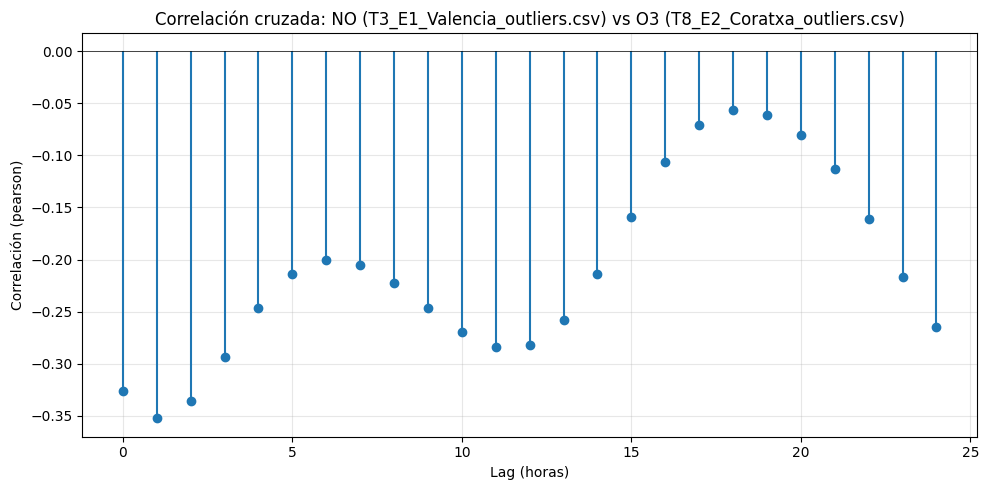


Resultados guardados en cross_corr_T3_E1_Valencia_outliers.csv_NO_vs_T8_E2_Coratxa_outliers.csv_O3.csv


: 

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================================
# CONFIGURACIÓN (¡CÁMBIALO A TUS RUTAS Y VARIABLES!)
# ============================================================================
# Rutas de los archivos CSV de las dos estaciones (ajusta a tus archivos)
ruta_estacion1 = "/Volumes/copia seguridad1/enviar_benja/carpeta sin título/clean/Finales/T3_E1_Valencia_outliers.csv"
ruta_estacion2 = "/Volumes/copia seguridad1/enviar_benja/carpeta sin título/clean/Finales/T7_E2_Coratxa_outliers.csv"

# Variables a correlacionar (ej. 'O3', 'NO2', 'NO')
var1 = 'NO'
var2 = 'O3'

# Rango de lags (horas). Por defecto ±24
lag_min = 0
lag_max = 24
step = 1

# Método de correlación: 'pearson', 'spearman', 'kendall'
corr_method = 'pearson'

# Umbral mínimo de datos comunes (fracción) para cada lag
min_common_frac = 0.5

# Si la fecha no es índice, especifica el nombre de la columna (ej. 'datetime')
fecha_col = None  # None asume que la primera columna es el índice datetime

# ============================================================================
# FUNCIONES
# ============================================================================
def load_series(filepath, var, fecha_col=None):
    """
    Carga la serie temporal de un archivo CSV.
    Si fecha_col es None, se asume que la primera columna es el índice datetime.
    """
    if fecha_col is None:
        df = pd.read_csv(filepath, index_col=0, parse_dates=True)
    else:
        df = pd.read_csv(filepath, parse_dates=[fecha_col])
        df.set_index(fecha_col, inplace=True)
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)
    if var not in df.columns:
        raise ValueError(f"Variable '{var}' no encontrada en {filepath}. Columnas: {df.columns.tolist()}")
    serie = pd.to_numeric(df[var], errors='coerce')
    return serie

def cross_correlation(serie1, serie2, lags, method='pearson', min_common=10):
    """
    Calcula la correlación cruzada entre dos series para una lista de lags.
    Retorna un diccionario {lag: corr}.
    """
    results = {}
    for lag in lags:
        if lag >= 0:
            # serie1 en t vs serie2 en t+lag
            s1 = serie1
            s2 = serie2.shift(-lag)
        else:
            # serie1 en t+lag vs serie2 en t (equivalente a lag negativo)
            s1 = serie1.shift(lag)
            s2 = serie2
        # Alinear y eliminar NaN
        combined = pd.concat([s1, s2], axis=1).dropna()
        if len(combined) < min_common:
            results[lag] = np.nan
        else:
            results[lag] = combined.iloc[:,0].corr(combined.iloc[:,1], method=method)
    return results

# ============================================================================
# EJECUCIÓN PRINCIPAL
# ============================================================================
if __name__ == "__main__":
    print("="*60)
    print(f"Correlación cruzada entre {os.path.basename(ruta_estacion1)} ({var1}) y")
    print(f"{os.path.basename(ruta_estacion2)} ({var2})")
    print(f"Rango de lags: {lag_min} a {lag_max} horas")
    print("="*60)

    # Cargar series
    try:
        s1 = load_series(ruta_estacion1, var1, fecha_col)
        s2 = load_series(ruta_estacion2, var2, fecha_col)
    except Exception as e:
        print(f"Error al cargar los datos: {e}")
        exit()

    print(f"Serie 1: {len(s1)} horas, {s1.isna().sum()} NaN")
    print(f"Serie 2: {len(s2)} horas, {s2.isna().sum()} NaN")

    # Definir lags
    lags = list(range(lag_min, lag_max+1, step))
    print(f"Lags a evaluar: {lags[0]} ... {lags[-1]} (total {len(lags)})")

    # Calcular correlación
    min_common = int(min(len(s1), len(s2)) * min_common_frac)
    min_common = max(min_common, 10)
    corr_results = cross_correlation(s1, s2, lags, method=corr_method, min_common=min_common)

    # Mostrar el lag de máxima correlación absoluta
    valid_results = {lag: corr for lag, corr in corr_results.items() if not np.isnan(corr)}
    if valid_results:
        max_lag = max(valid_results, key=lambda l: abs(valid_results[l]))
        max_corr = valid_results[max_lag]
        print(f"\nMáxima correlación |{max_corr:.3f}| en lag = {max_lag} horas")
        if max_lag > 0:
            print(f"Interpretación: {var2} en {os.path.basename(ruta_estacion2)} se retrasa {max_lag} horas respecto a {var1} en {os.path.basename(ruta_estacion1)}")
        elif max_lag < 0:
            print(f"Interpretación: {var1} en {os.path.basename(ruta_estacion1)} se retrasa {-max_lag} horas respecto a {var2} en {os.path.basename(ruta_estacion2)}")
        else:
            print("Correlación máxima en lag 0 (simultánea)")
    else:
        print("No se obtuvieron correlaciones válidas con el umbral actual.")

    # Gráfico
    plt.figure(figsize=(10, 5))
    lags_sorted = sorted(corr_results.keys())
    values = [corr_results[l] for l in lags_sorted]
    plt.stem(lags_sorted, values, basefmt=" ")
    plt.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
    plt.xlabel('Lag (horas)')
    plt.ylabel(f'Correlación ({corr_method})')
    plt.title(f'Correlación cruzada: {var1} ({os.path.basename(ruta_estacion1)}) vs {var2} ({os.path.basename(ruta_estacion2)})')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Guardar resultados en CSV
    df_results = pd.DataFrame(list(corr_results.items()), columns=['lag', 'correlacion'])
    output_csv = f"cross_corr_{os.path.basename(ruta_estacion1)}_{var1}_vs_{os.path.basename(ruta_estacion2)}_{var2}.csv"
    df_results.to_csv(output_csv, index=False)
    print(f"\nResultados guardados en {output_csv}")